## HealthGuard Insurance Pricing Predictions
The purpose of this script is to understand the customers of HealthGuard and prdict their medical charges.

Dataset from https://www.kaggle.com/datasets/mirichoi0218/insurance

### Step 1: Understanding Customers

Load the data and show the most important customer attributes.

#### Data Cleaning
Start Cleaning data by converting fields to valid datatypes. In this set, these are the sex, smoker, and region.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import the data from the csv file
df = pd.read_csv('insurance.csv') 
print(df.info())

# Display all unique values
print(f'All sex values: {df['sex'].unique().tolist()}')
print(f'All smoker values: {df['smoker'].unique().tolist()}')
print(f'All region values: {df['region'].unique().tolist()}')

# Start one-hot encoding
target = df['charges']
fields = df.drop(['sex', 'smoker', 'region', 'charges'], axis=1)
fields['is_smoker'] = np.where(df['smoker'] == 'yes', 1, 0)
fields['is_female'] = np.where(df['sex'] == 'female', 1, 0)

# One-hot encode the regions
fields['region_sw'] = np.where(df['region'] == 'southwest', 1, 0)
fields['region_se'] = np.where(df['region'] == 'southeast', 1, 0)
fields['region_nw'] = np.where(df['region'] == 'northwest', 1, 0)


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None
All sex values: ['female', 'male']
All smoker values: ['yes', 'no']
All region values: ['southwest', 'southeast', 'northwest', 'northeast']


#### Meaningful Visualizations
Show some graphs that demonstrate which attributes affect the charge (age, sex, bmi, children, smoker, region)

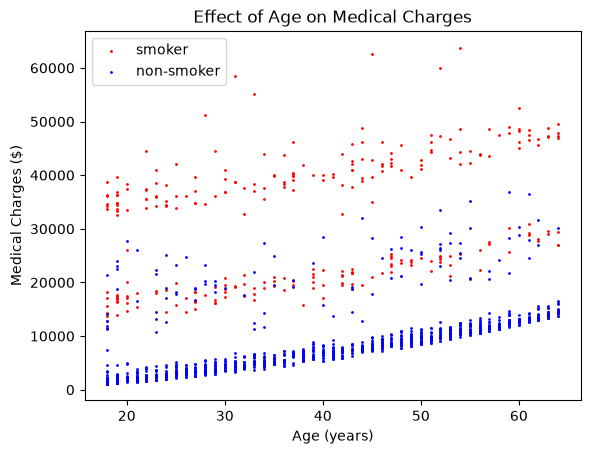

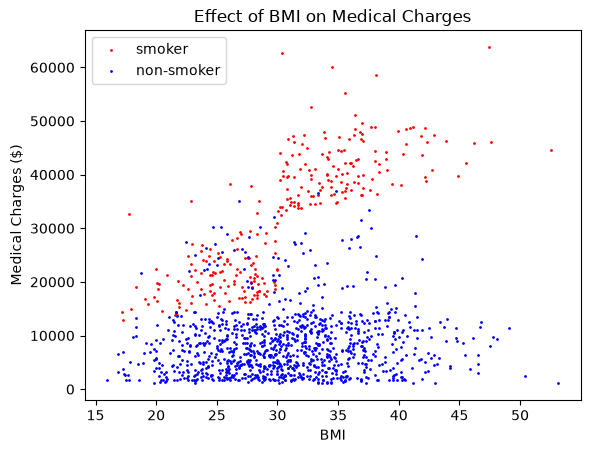

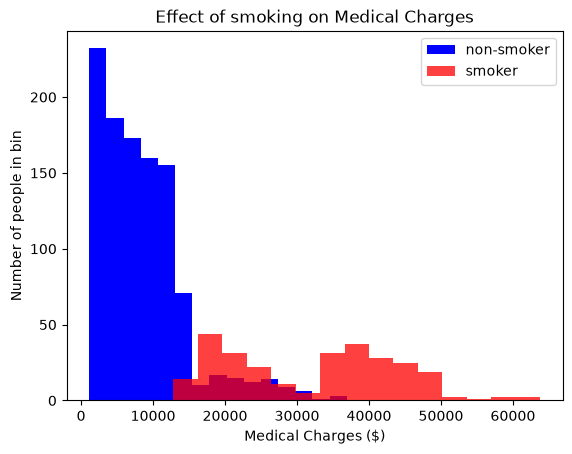

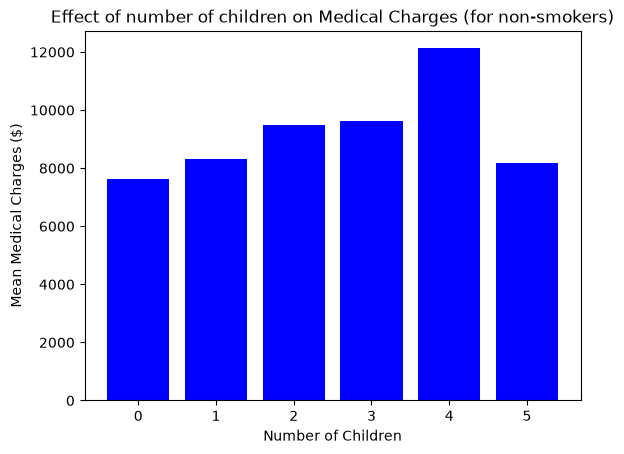

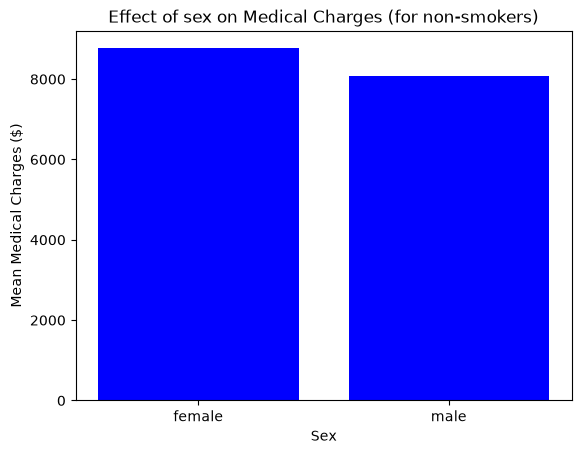

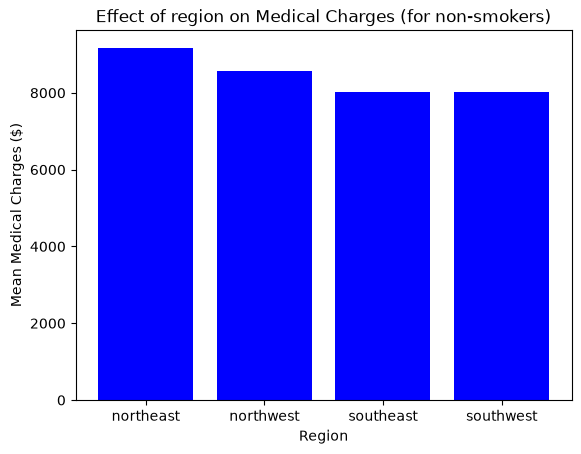

In [41]:
# Create masks
smoker_mask = fields['is_smoker'] == 1
non_smoker_mask = fields['is_smoker'] == 0

# Show age vs medical charges
plt.scatter(fields['age'][smoker_mask], target[smoker_mask], s=1, color='r', label='smoker')
plt.scatter(fields['age'][non_smoker_mask], target[non_smoker_mask], s=1, color='b', label='non-smoker')
plt.title('Effect of Age on Medical Charges')
plt.ylabel('Medical Charges ($)')
plt.xlabel('Age (years)')
plt.legend()
plt.show()

# Show BMI vs medical charges
plt.scatter(fields['bmi'][smoker_mask], target[smoker_mask], s=1, color='r', label='smoker')
plt.scatter(fields['bmi'][non_smoker_mask], target[non_smoker_mask], s=1, color='b', label='non-smoker')
plt.title('Effect of BMI on Medical Charges')
plt.ylabel('Medical Charges ($)')
plt.xlabel('BMI')
plt.legend()
plt.show()

# HISTOGRAM

# Show smoking vs medical charges
plt.hist(target[non_smoker_mask], bins=15, color='b', label='non-smoker')
plt.hist(target[smoker_mask], bins=15, color='r', alpha=0.75, label='smoker')
plt.title('Effect of smoking on Medical Charges')
plt.ylabel('Number of people in bin')
plt.xlabel('Medical Charges ($)')
plt.legend()
plt.show()

# BAR PLOTS

# Show number of children vs medical charges
avg_by_children = df[non_smoker_mask].groupby('children')['charges'].mean()
plt.bar(avg_by_children.index, avg_by_children.values, color='b')
plt.title('Effect of number of children on Medical Charges (for non-smokers)')
plt.ylabel('Mean Medical Charges ($)')
plt.xlabel('Number of Children')
plt.show()

# Show number of children vs medical charges
avg_by_children = df[non_smoker_mask].groupby('sex')['charges'].mean()
plt.bar(avg_by_children.index, avg_by_children.values, color='b')
plt.title('Effect of sex on Medical Charges (for non-smokers)')
plt.ylabel('Mean Medical Charges ($)')
plt.xlabel('Sex')
plt.show()

# Show number of children vs medical charges
avg_by_children = df[non_smoker_mask].groupby('region')['charges'].mean()
plt.bar(avg_by_children.index, avg_by_children.values, color='b')
plt.title('Effect of region on Medical Charges (for non-smokers)')
plt.ylabel('Mean Medical Charges ($)')
plt.xlabel('Region')
plt.show()

### Step 2: Predicting Medical Charges
Predict the medical charges using different parameters

#### Algorithm 1: Simple Linear Regression

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. SPLIT into train and test
X_train, X_test, y_train, y_test = train_test_split(
    fields[['is_smoker']], target, test_size=0.2, random_state=42)

# 2. FIT the model on the training data only
My_model=model = LinearRegression()
My_model.fit(X_train, y_train)

# 3. PREDICT on the unseen test data
y_pred = My_model.predict(X_test)

# 4. EVALUATE against the true test values
print("The best predictor is whether a customer smokes. Using just this parameter gives the following:")
print(f"R2: {round(r2_score(y_test, y_pred), 4)}")
print(f"MAE: ${round(mean_absolute_error(y_test, y_pred), 2)}")
print(f"MSE: ${round(mean_squared_error(y_test, y_pred), 2)}")
print(f"RMSE: ${round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)}\n")

print(f"Price for non-smokers (bias): ${round(My_model.intercept_, 2)}")
print(f"Addition for smokers (weight): ${round(My_model.coef_[0], 2)}")





The best predictor is whether a customer smokes. Using just this parameter gives the following:
R2: 0.6602
MAE: $5625.81
MSE: $52745964.73
RMSE: $7262.64

Price for non-smokers (bias): $8578.32
Addition for smokers (weight): $23188.69


#### Algorithm 2: Multivariable Linear Regression

In [43]:
# 1. SPLIT into train and test
X_train, X_test, y_train, y_test = train_test_split(
    fields, target, test_size=0.2, random_state=42)

# 2. FIT the model on the training data only
My_model=model = LinearRegression()
My_model.fit(X_train, y_train)

# 3. PREDICT on the unseen test data
y_pred = My_model.predict(X_test)

# 4. EVALUATE against the true test values
print("Using linear regression on all variables gives the following:")
print(f"R2: {round(r2_score(y_test, y_pred), 4)}")
print(f"MAE: ${round(mean_absolute_error(y_test, y_pred), 2)}")
print(f"MSE: ${round(mean_squared_error(y_test, y_pred), 2)}")
print(f"RMSE: ${round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)}\n")

print(f"Bias: ${round(My_model.intercept_, 2)}")
for name, coef in zip(X_train.columns, My_model.coef_):
    print(f"Weight for {name}: ${round(coef, 2)}")


Using linear regression on all variables gives the following:
R2: 0.7836
MAE: $4181.19
MSE: $33596915.85
RMSE: $5796.28

Bias: $-11949.81
Weight for age: $256.98
Weight for bmi: $337.09
Weight for children: $425.28
Weight for is_smoker: $23651.13
Weight for is_female: $18.59
Weight for region_sw: $-809.8
Weight for region_se: $-657.86
Weight for region_nw: $-370.68


#### Algorithm 3: Polynomial Linear Regression

In [44]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Test degrees 2, 3, and 4
for degree in [2, 3, 4]:

    # Train the polynomial model
    model = make_pipeline( PolynomialFeatures(degree=degree, include_bias=False), LinearRegression())
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred = model.predict(X_test)
    
    # Print the results
    print(f"Degree: {degree}")
    print(f"R2: {round(r2_score(y_train, y_pred_train), 4)} (train), {round(r2_score(y_test, y_pred), 4)} (test)")
    print(f"MAE: ${round(mean_absolute_error(y_test, y_pred), 2)}")
    print(f"MSE: ${round(mean_squared_error(y_test, y_pred), 2)}")
    print(f"RMSE: ${round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)}\n")


Degree: 2
R2: 0.8418 (train), 0.8666 (test)
MAE: $2729.5
MSE: $20712805.99
RMSE: $4551.13

Degree: 3
R2: 0.8474 (train), 0.8654 (test)
MAE: $2879.49
MSE: $20891909.31
RMSE: $4570.77

Degree: 4
R2: 0.8513 (train), 0.8581 (test)
MAE: $2960.15
MSE: $22036709.53
RMSE: $4694.33



As can be seen, degree 2 performs the best (with a R^2 of 0.8666). As the degree increases, the train R^2 increases but the test R^2 decreases, which is a classic indicator of overfitting.

#### Algorithm 4: Ridge Regression (L2)

In [45]:
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.fit_transform(X_test)

test_alphas = [0.01, 0.05, 0.1, 0.5, 0.8, 1, 10, 100, 1000]
for alpha in test_alphas:
    model = linear_model.Ridge(alpha=alpha)
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)


    print(f"Alpha = {alpha}, R2: {round(r2_score(y_test, y_pred), 4)}")
    if alpha == 1:
        print(f"MAE: ${round(mean_absolute_error(y_test, y_pred), 2)}")
        print(f"MSE: ${round(mean_squared_error(y_test, y_pred), 2)}")
        print(f"RMSE: ${round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)}\n")


Alpha = 0.01, R2: 0.7834
Alpha = 0.05, R2: 0.7834
Alpha = 0.1, R2: 0.7834
Alpha = 0.5, R2: 0.7834
Alpha = 0.8, R2: 0.7834
Alpha = 1, R2: 0.7834
MAE: $4187.71
MSE: $33633901.07
RMSE: $5799.47

Alpha = 10, R2: 0.7829
Alpha = 100, R2: 0.774
Alpha = 1000, R2: 0.5881


As can be seen, the best alpha is around 1. However, increasing alpha does not change performance until alpha is greater than 1, where performance starts dropping. This is because there are not that many attributes.

#### Algorithm 5: Lasso Regression (L1)

In [46]:
test_alphas = [0.01, 0.05, 0.1, 0.5, 0.8, 1, 10, 100, 1000]
for alpha in test_alphas:
    model = linear_model.Lasso(alpha=alpha)
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)


    print(f"Alpha = {alpha}, R2: {round(r2_score(y_test, y_pred), 4)}")
    if alpha == 1:
        print(f"MAE: ${round(mean_absolute_error(y_test, y_pred), 2)}")
        print(f"MSE: ${round(mean_squared_error(y_test, y_pred), 2)}")
        print(f"RMSE: ${round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)}\n")
    print(f"Columns removed: {[n for n, c in zip(X_train.columns, model.coef_) if c == 0]}\n")



Alpha = 0.01, R2: 0.7834
Columns removed: []

Alpha = 0.05, R2: 0.7834
Columns removed: []

Alpha = 0.1, R2: 0.7834
Columns removed: []

Alpha = 0.5, R2: 0.7834
Columns removed: []

Alpha = 0.8, R2: 0.7834
Columns removed: []

Alpha = 1, R2: 0.7834
MAE: $4186.27
MSE: $33631303.77
RMSE: $5799.25

Columns removed: []

Alpha = 10, R2: 0.7831
Columns removed: ['is_female']

Alpha = 100, R2: 0.7806
Columns removed: ['is_female', 'region_nw']

Alpha = 1000, R2: 0.7549
Columns removed: ['children', 'is_female', 'region_sw', 'region_se', 'region_nw']



This indicates that the optimal alpha is 0.7836, where no features are removed. The least significant features are sex, region, and number of children.

#### Algorithm 6: SVR

In [47]:
from sklearn.svm import SVR

eps = 0.1   # I don't care about errors of 1.5 or less; the line just has to pass within 1.5 units of every point.

# Scale y
scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

kernels = ['linear', 'rbf', 'poly']
# Test a three kernels
for kernel in kernels:
    svr = SVR(kernel=kernel, C=1, epsilon=eps)
    svr.fit(X_train_s, y_train_s)
    y_pred_s = svr.predict(X_test_s)
    y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()

    # 5. Evaluate
    print(f"Kernel: {kernel}")
    print(f"R2: {round(r2_score(y_test, y_pred), 4)}")
    print(f"MAE: ${round(mean_absolute_error(y_test, y_pred), 2)}")
    print(f"MSE: ${round(mean_squared_error(y_test, y_pred), 2)}")
    print(f"RMSE: ${round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)}\n")

Kernel: linear
R2: 0.7373
MAE: $3322.12
MSE: $40791352.5
RMSE: $6386.81

Kernel: rbf
R2: 0.865
MAE: $2608.92
MSE: $20958145.6
RMSE: $4578.01

Kernel: poly
R2: 0.852
MAE: $2533.06
MSE: $22971747.32
RMSE: $4792.89



#### Algorithm 7: Decision Tree Regression

Depth: 2
R2: 0.8235 (train), 0.8321 (test)
MAE: $3299.97
MSE: $26071833.63
RMSE: $5106.06

Depth: 3
R2: 0.8537 (train), 0.8531 (test)
MAE: $2865.64
MSE: $22812669.85
RMSE: $4776.26

Depth: 4
R2: 0.8653 (train), 0.8641 (test)
MAE: $2697.77
MSE: $21093484.0
RMSE: $4592.76



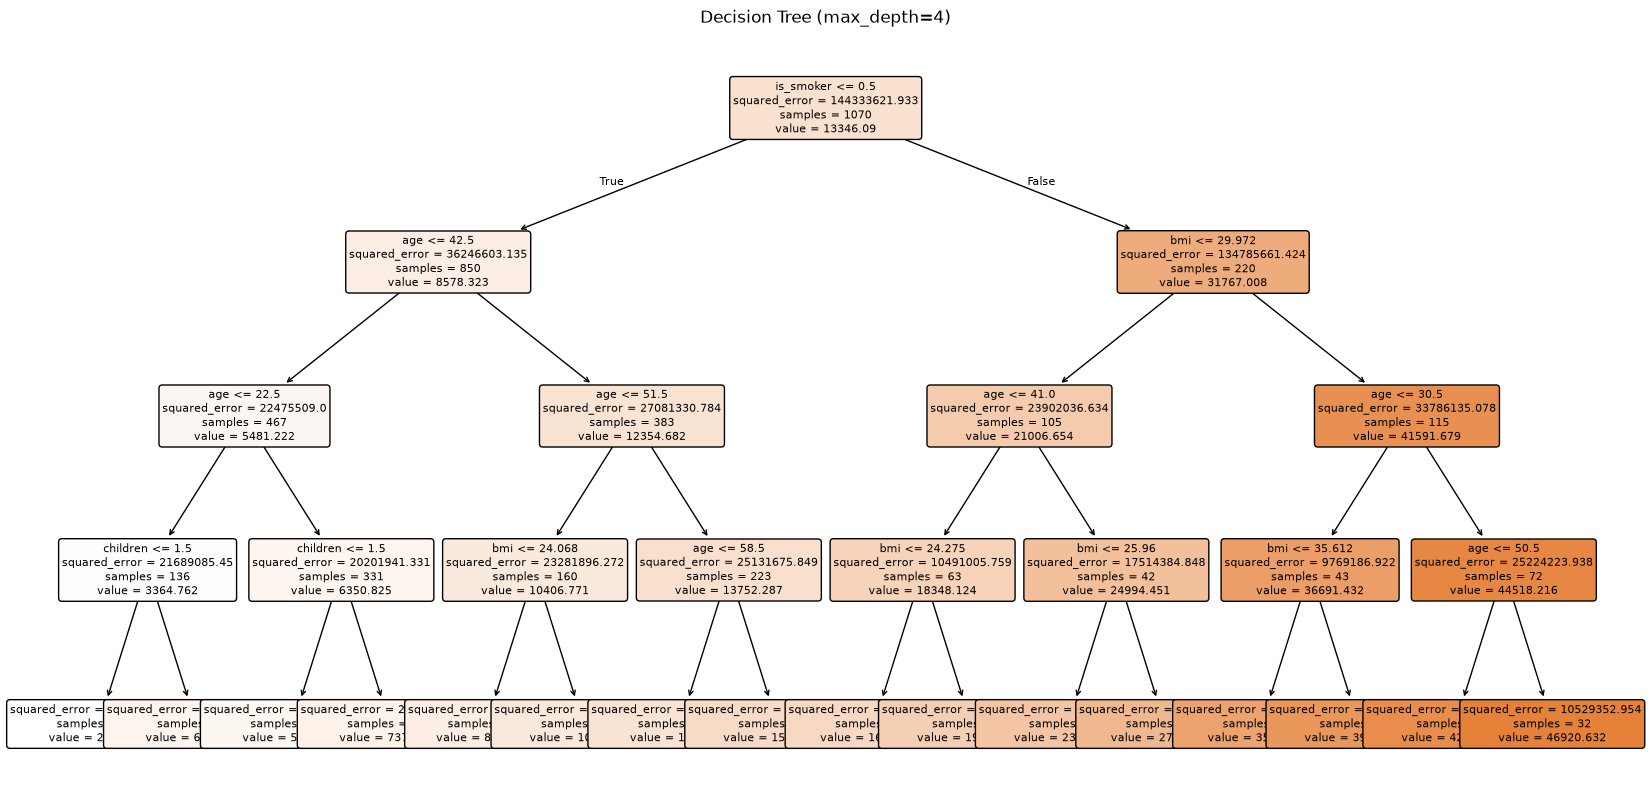

Depth: 5
R2: 0.8798 (train), 0.8336 (test)
MAE: $2930.77
MSE: $25831862.6
RMSE: $5082.51

Depth: 6
R2: 0.891 (train), 0.8237 (test)
MAE: $2844.44
MSE: $27372351.04
RMSE: $5231.86

Depth: 7
R2: 0.9113 (train), 0.8011 (test)
MAE: $3006.57
MSE: $30884159.97
RMSE: $5557.35

Depth: 8
R2: 0.9331 (train), 0.7549 (test)
MAE: $2912.56
MSE: $38051408.31
RMSE: $6168.58



In [52]:
from sklearn import tree
from sklearn.tree import plot_tree

depths_to_test = [2, 3, 4, 5, 6, 7, 8]
for depth in depths_to_test:
    tree_model = tree.DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree_model.fit(X_train, y_train)

    y_pred_train = tree_model.predict(X_train)
    y_pred = tree_model.predict(X_test)

    print(f"Depth: {depth}")
    print(f"R2: {round(r2_score(y_train, y_pred_train), 4)} (train), {round(r2_score(y_test, y_pred), 4)} (test)")
    print(f"MAE: ${round(mean_absolute_error(y_test, y_pred), 2)}")
    print(f"MSE: ${round(mean_squared_error(y_test, y_pred), 2)}")
    print(f"RMSE: ${round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)}\n")

    if depth == 4:
        plt.figure(figsize=(20, 10))
        plot_tree(tree_model, feature_names=X_train.columns, filled=True, rounded=True, fontsize=8)
        plt.title(f'Decision Tree (max_depth={depth})')
        plt.show()

